In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('superstore_final_dataset (1).csv',encoding="latin1")
df.head(10)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680
5,6,CA-2015-115812,09-06-2015,14-06-2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09-06-2015,14-06-2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09-06-2015,14-06-2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09-06-2015,14-06-2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09-06-2015,14-06-2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [3]:
# Clean up the column headers to make them easier to type
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# Check the new names
print("New column names:", df.columns.tolist())

New column names: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales']


In [4]:
# Convert Order_Date and Ship_Date to datetime objects
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True)
print(df['order_date'])
print(df['ship_date'])

# Create extra columns for time-based analysis
df['YearMonth'] = df['order_date'].dt.to_period('M').astype(str)
df['Year'] = df['order_date'].dt.year
print(df['YearMonth'])
print(df['Year'])
print("Data cleaning complete. Date columns converted.")

0      2017-11-08
1      2017-11-08
2      2017-06-12
3      2016-10-11
4      2016-10-11
          ...    
9795   2017-05-21
9796   2016-01-12
9797   2016-01-12
9798   2016-01-12
9799   2016-01-12
Name: order_date, Length: 9800, dtype: datetime64[ns]
0      2017-11-11
1      2017-11-11
2      2017-06-16
3      2016-10-18
4      2016-10-18
          ...    
9795   2017-05-28
9796   2016-01-17
9797   2016-01-17
9798   2016-01-17
9799   2016-01-17
Name: ship_date, Length: 9800, dtype: datetime64[ns]
0       2017-11
1       2017-11
2       2017-06
3       2016-10
4       2016-10
         ...   
9795    2017-05
9796    2016-01
9797    2016-01
9798    2016-01
9799    2016-01
Name: YearMonth, Length: 9800, dtype: object
0       2017
1       2017
2       2017
3       2016
4       2016
        ... 
9795    2017
9796    2016
9797    2016
9798    2016
9799    2016
Name: Year, Length: 9800, dtype: int32
Data cleaning complete. Date columns converted.


In [5]:
# Total Revenue
total_revenue = df['sales'].sum()

# Total Unique Orders
total_orders = df['order_id'].nunique()

# Average Order Value (Total Sales / Total Orders)
aov = total_revenue / total_orders

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Unique Orders: {total_orders}")
print(f"Average Order Value: {aov:,.2f}")

Total Revenue: 2,261,536.78
Total Unique Orders: 4922
Average Order Value: 459.48


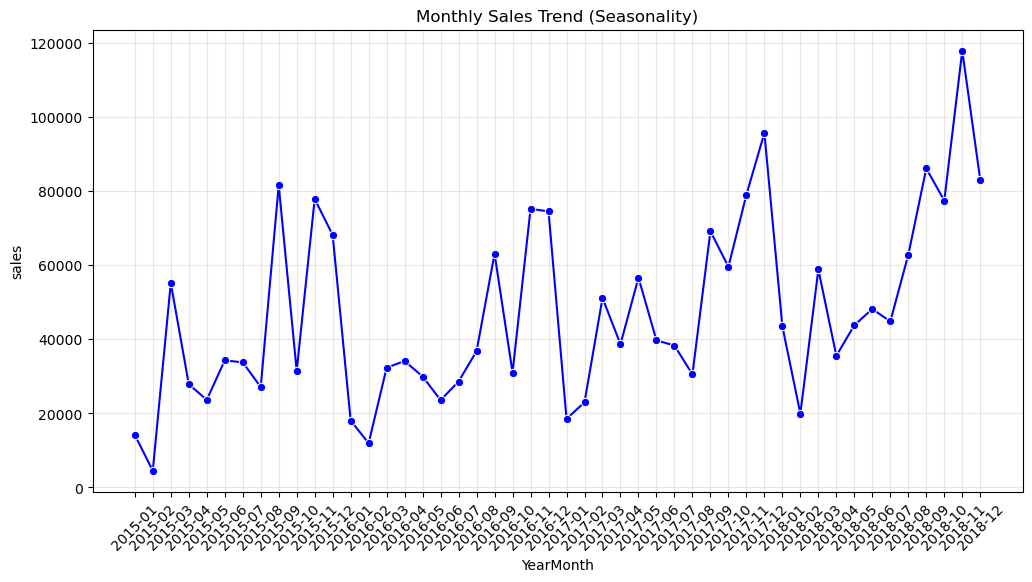

In [6]:
# Grouping sales by Year-Month
monthly_sales = df.groupby('YearMonth')['sales'].sum().reset_index()

# Plotting the trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='YearMonth', y='sales', marker='o', color='b')
plt.title('Monthly Sales Trend (Seasonality)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\91899\AppData\Local\Temp\ipykernel_18320\3186254429.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regional_sales, x='region', y='sales', palette='viridis')


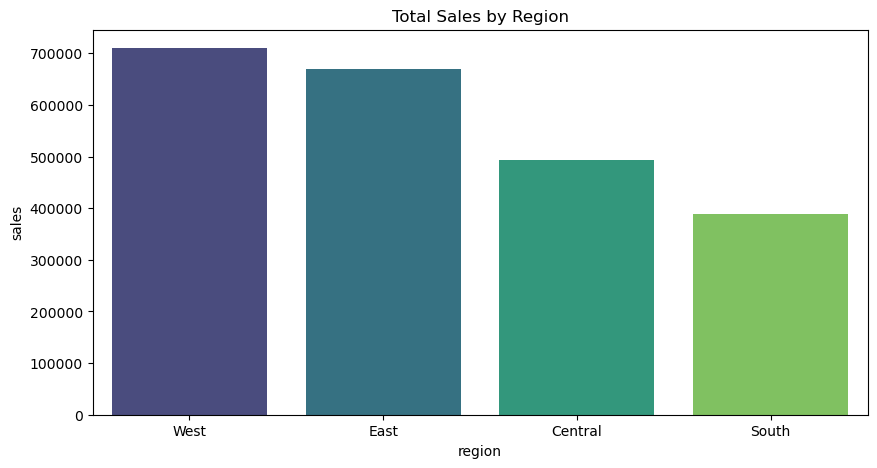

In [12]:
# Regional Performance
regional_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False).reset_index()

# Category Performance
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False).reset_index()

# Visualizing Regional Sales
plt.figure(figsize=(10, 5))
sns.barplot(data=regional_sales, x='region', y='sales', palette='viridis')
plt.title('Total Sales by Region')
plt.show()

C:\Users\91899\AppData\Local\Temp\ipykernel_18320\2907711373.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='sales', y='product_name', palette='Greens_r')


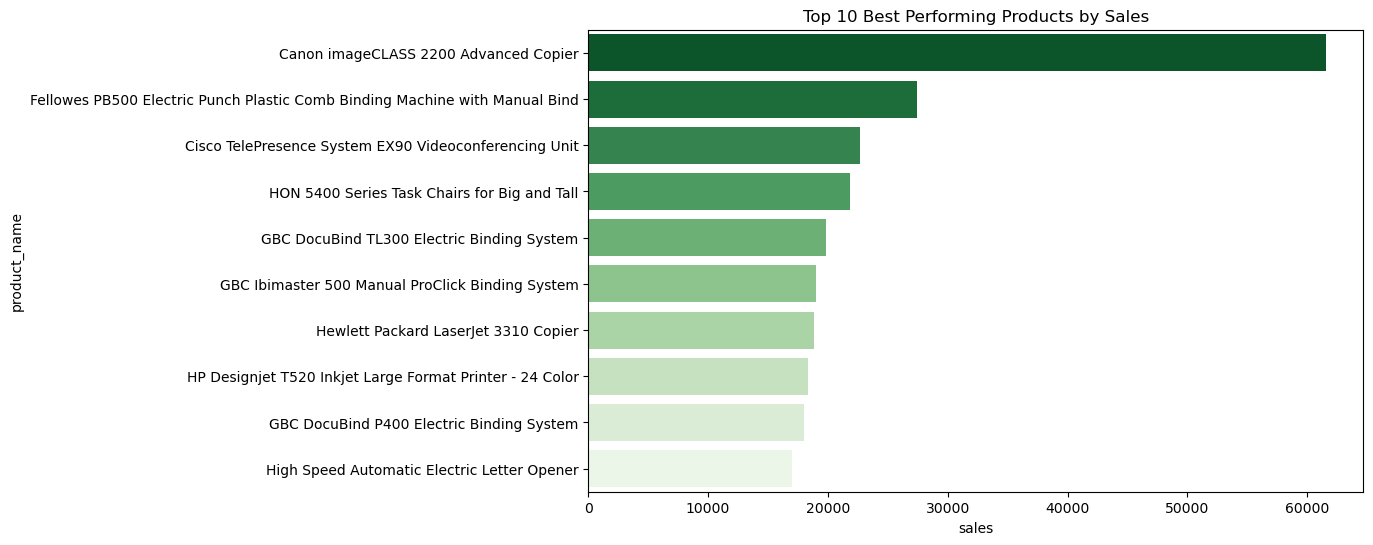

C:\Users\91899\AppData\Local\Temp\ipykernel_18320\2907711373.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_products, x='sales', y='product_name', palette='Reds_r')


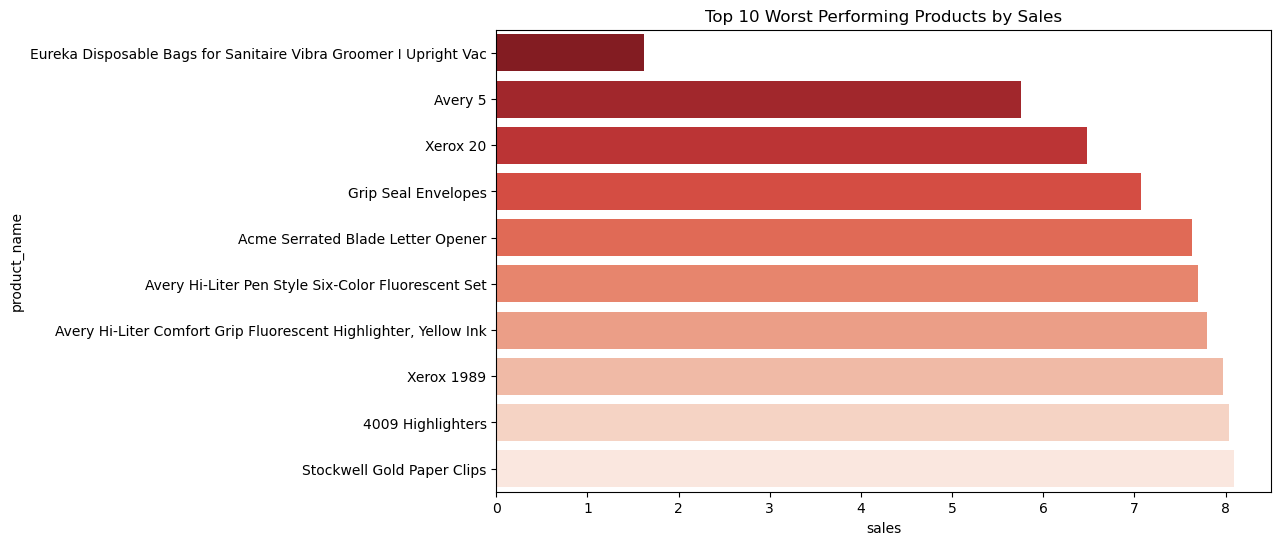

In [13]:
# Top 10 Best Performing Products
top_products = df.groupby('product_name')['sales'].sum().nlargest(10).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='sales', y='product_name', palette='Greens_r')
plt.title('Top 10 Best Performing Products by Sales')
plt.show()

# Top 10 Worst Performing Products
worst_products = df.groupby('product_name')['sales'].sum().nsmallest(10).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=worst_products, x='sales', y='product_name', palette='Reds_r')
plt.title('Top 10 Worst Performing Products by Sales')
plt.show()

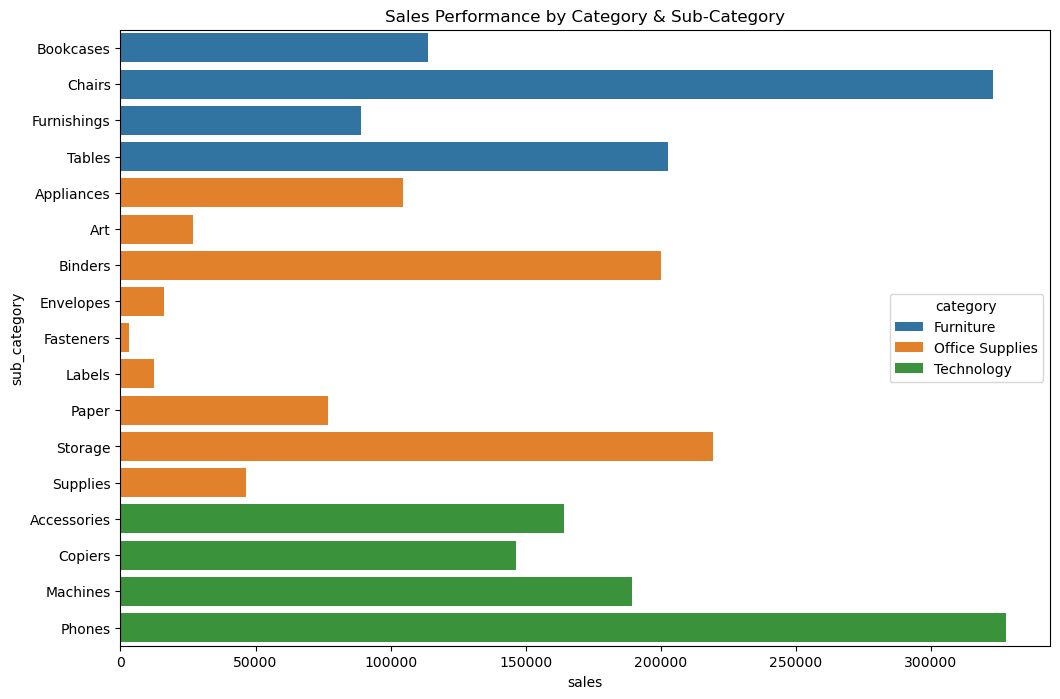

In [10]:
# Sales by Category and Sub-Category
cat_sales = df.groupby(['category', 'sub_category'])['sales'].sum().reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=cat_sales, x='sales', y='sub_category', hue='category', dodge=False)
plt.title('Sales Performance by Category & Sub-Category')
plt.show()